In [6]:
import pandas as pd
import numpy as np

In [7]:
dfSus=pd.read_csv("Ranking_unis - Foglio1.csv")
dfProf=pd.read_csv("8_Dataset finale.xlsx - Dataset 20-23.csv")

UNIVERSITY_ID
Bari                  73.20
Bari Politecnico        NaN
Basilicata              NaN
Bergamo                 NaN
Bologna               86.55
                      ...  
Udine                   NaN
Urbino                  NaN
Venezia Cà Foscari      NaN
Venezia Iuav            NaN
Verona                73.20
Name: OVERALL, Length: 61, dtype: float64

In [8]:
cols = pd.Index(dfProf.columns)

# replace Unnamed with NA
clean = cols.to_series().replace(r"Unnamed:.*", pd.NA, regex=True)

# forward-fill across columns (this fixes merged Excel headers)
clean = clean.ffill()

dfProf.columns = clean

new_cols = (
    pd.Index(dfProf.columns).astype(str)
    + " | " +
    dfProf.iloc[0].astype(str).values
)

dfProf.columns = new_cols
dfProf = dfProf.iloc[1:].reset_index(drop=True)

In [9]:
dfProf

,IDENTIFIERS | UNIVERSITY_ID,IDENTIFIERS | YEAR,STAFF | INTERNAL TEACHING STAFF,STAFF | AVERAGE AGE OF INTERNAL TEACHING STAFF,STAFF | FULL PROFESSORS,STAFF | AVERAGE AGE OF FULL PROFESSORS,STAFF | ASSOCIATE PROFESSOR,STAFF | AVERAGE AGE OF ASSOCIATE PROFESSORS,STAFF | TENURED RESEARCHERS,STAFF | AVERAGE AGE OF TENURED RESEARCHERS,...,ECONOMIC AND FINANCIAL | ECONOMIC AND FINANCIAL SUSTAINABILITY INDEX,ECONOMIC AND FINANCIAL | FFO (ANVUR),ECONOMIC AND FINANCIAL | FFO (DM),ECONOMIC AND FINANCIAL | BASE FUNDING QUOTA,ECONOMIC AND FINANCIAL | PERFORMANCE-BASED FUNDING QUOTA,ECONOMIC AND FINANCIAL | EQUALISATION INTERVENTIONS,ECONOMIC AND FINANCIAL | EXTRAORDINARY FUNDING PLANS,ECONOMIC AND FINANCIAL | STANDARD COST PER STUDENT,RESEARCH | HIGHLY CITED RESEARCHERS,RESEARCH | ARTICLES PUBLISHED IN NATURE AND SCIENCE
0,Bari,2020,1520,"51,2",272,"58,9",523,"53,2",425,"52,5",...,"1,295139796",0,179692122,117682112,46634445,7073805,8124512,7113,57,3
1,Bari Politecnico,2020,326,"49,5",78,"56,6",120,"52,4",34,"52,5",...,"1,336506781",0,41043094,27304719,11276408,141063,2317369,8334,21,2
2,Basilicata,2020,320,"53,9",50,"62,1",136,"55,4",91,"53,3",...,"1,212724412",0,30155605,17855887,9188640,781202,2310301,9059,9,0
3,Bergamo,2020,375,"50,5",91,"58,7",161,51,48,"51,1",...,"1,526341722",0,55082751,38365377,15078631,0,3420748,5654,5,0
4,Bologna,2020,2850,"51,2",771,"57,6",1249,"51,3",334,"54,1",...,"1,264251529",0,374684109,225431066,118865396,5518552,24730817,6700,226,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,Udine,2023,692,"53,3",166,"60,1",306,54,98,57,...,"1,182940073",93041992,81999472,44642751,27125947,1173407,9054563,7483,41,2
240,Urbino,2023,367,"53,5",80,60,161,"54,1",46,"58,6",...,"1,312181744",66660633,58396386,35794523,15628061,589260,6383134,6103,15,0
241,Venezia Cà Foscari,2023,714,"49,8",182,"57,7",302,"51,2",27,"56,8",...,"1,217717585",109510860,91946632,49887661,30745744,1062416,10248272,5554,24,2
242,Venezia Iuav,2023,179,"52,6",48,"59,9",78,"53,6",6,"62,8",...,"1,289681124",35425887,30016756,17139234,7939200,1744896,3189256,7974,4,0


In [10]:
dfSus.columns[0:1]

Index(['Identifiers'], dtype='object')

In [11]:
dfUI=dfSus[dfSus.columns[0:8]]

cols = [dfSus.columns[0]] + list(dfSus.columns[8:])
dfTHE = dfSus[cols]

In [12]:
new_cols = (dfUI.iloc[0].astype(str).values)

dfUI.columns = new_cols
dfUI = dfUI.iloc[1:].reset_index(drop=True)

In [13]:
dfUI

,UNIVERSITY_ID,GLOBAL,SI,EC,WS,WR,TR,ED
0,Bari,"6862,5",850,1275,1425,900,1400,"1012,5"
1,Bari Politecnico,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Basilicata,"7787,5",1300,1625,1575,"537,5","1287,5","1462,5"
3,Bergamo,6115,740,1700,1225,"347,5",1075,"1027,5"
4,Bologna,"9487,5",1350,1825,1800,"912,5",1800,1800
...,...,...,...,...,...,...,...,...
56,Udine,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,Urbino,"7857,5",910,1875,1600,735,1375,"1362,5"
58,Venezia Cà Foscari,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,Venezia Iuav,5530,645,1225,700,725,1010,1225


In [14]:
dfProf = dfProf.rename(columns={
    "IDENTIFIERS | UNIVERSITY_ID": "UNIVERSITY_ID"
})

In [15]:
UI = dfProf.merge(dfUI, how='left', on='UNIVERSITY_ID')

In [16]:
UI.head(5)

,UNIVERSITY_ID,IDENTIFIERS | YEAR,STAFF | INTERNAL TEACHING STAFF,STAFF | AVERAGE AGE OF INTERNAL TEACHING STAFF,STAFF | FULL PROFESSORS,STAFF | AVERAGE AGE OF FULL PROFESSORS,STAFF | ASSOCIATE PROFESSOR,STAFF | AVERAGE AGE OF ASSOCIATE PROFESSORS,STAFF | TENURED RESEARCHERS,STAFF | AVERAGE AGE OF TENURED RESEARCHERS,...,ECONOMIC AND FINANCIAL | STANDARD COST PER STUDENT,RESEARCH | HIGHLY CITED RESEARCHERS,RESEARCH | ARTICLES PUBLISHED IN NATURE AND SCIENCE,GLOBAL,SI,EC,WS,WR,TR,ED
0,Bari,2020,1520,"51,2",272,"58,9",523,"53,2",425,"52,5",...,7113,57,3,"6862,5",850,1275,1425,900,1400,"1012,5"
1,Bari Politecnico,2020,326,"49,5",78,"56,6",120,"52,4",34,"52,5",...,8334,21,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Basilicata,2020,320,"53,9",50,"62,1",136,"55,4",91,"53,3",...,9059,9,0,"7787,5",1300,1625,1575,"537,5","1287,5","1462,5"
3,Bergamo,2020,375,"50,5",91,"58,7",161,51,48,"51,1",...,5654,5,0,6115,740,1700,1225,"347,5",1075,"1027,5"
4,Bologna,2020,2850,"51,2",771,"57,6",1249,"51,3",334,"54,1",...,6700,226,12,"9487,5",1350,1825,1800,"912,5",1800,1800


In [17]:
df = UI.copy()

df["IDENTIFIERS | YEAR"] = df["IDENTIFIERS | YEAR"].astype(int)
df["UNIVERSITY_ID"] = df["UNIVERSITY_ID"]

In [18]:
df = df.replace(",", "", regex=True)
df = df.apply(pd.to_numeric, errors="ignore")

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_747/4282428895.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [19]:
df = df.sort_values(["UNIVERSITY_ID", "IDENTIFIERS | YEAR"])

In [20]:
wide = df.set_index(["UNIVERSITY_ID", "IDENTIFIERS | YEAR"]).unstack("IDENTIFIERS | YEAR")

In [21]:
wide.columns = [
    f"{col[0]}_{col[1]}" for col in wide.columns
]

In [22]:
df_2023 = df[df["IDENTIFIERS | YEAR"] == 2023].set_index("UNIVERSITY_ID")

In [23]:
df_final = df_2023.join(wide, how="left")

In [24]:
df

,UNIVERSITY_ID,IDENTIFIERS | YEAR,STAFF | INTERNAL TEACHING STAFF,STAFF | AVERAGE AGE OF INTERNAL TEACHING STAFF,STAFF | FULL PROFESSORS,STAFF | AVERAGE AGE OF FULL PROFESSORS,STAFF | ASSOCIATE PROFESSOR,STAFF | AVERAGE AGE OF ASSOCIATE PROFESSORS,STAFF | TENURED RESEARCHERS,STAFF | AVERAGE AGE OF TENURED RESEARCHERS,...,ECONOMIC AND FINANCIAL | STANDARD COST PER STUDENT,RESEARCH | HIGHLY CITED RESEARCHERS,RESEARCH | ARTICLES PUBLISHED IN NATURE AND SCIENCE,GLOBAL,SI,EC,WS,WR,TR,ED
0,Bari,2020,1520,512,272,589,523,532,425,525,...,7113,57,3,68625.0,850.0,1275.0,1425.0,900.0,1400.0,10125.0
61,Bari,2021,1511,514,290,584,591,525,332,538,...,6798,58,3,68625.0,850.0,1275.0,1425.0,900.0,1400.0,10125.0
122,Bari,2022,1537,513,287,586,689,526,218,55,...,6721,64,5,68625.0,850.0,1275.0,1425.0,900.0,1400.0,10125.0
183,Bari,2023,1575,509,313,583,660,529,208,556,...,6863,76,3,68625.0,850.0,1275.0,1425.0,900.0,1400.0,10125.0
1,Bari Politecnico,2020,326,495,78,566,120,524,34,525,...,8334,21,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,Venezia Iuav,2023,179,526,48,599,78,536,6,628,...,7974,4,0,5530.0,645.0,1225.0,700.0,725.0,1010.0,1225.0
60,Verona,2020,769,506,179,582,339,509,102,523,...,6179,39,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121,Verona,2021,792,508,175,584,365,511,93,532,...,6093,41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
182,Verona,2022,838,505,192,585,396,511,58,559,...,6124,44,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
for col in df_2023.columns:
    if col == "IDENTIFIERS | YEAR":
        continue
    df_final[f"{col}_chg_1y"] = (
        df_final[f"{col}_2023"] - df_final[f"{col}_2022"]
    )

In [26]:
df_final[f"{col}_chg_2y"] = (
    df_final[f"{col}_2023"] - df_final[f"{col}_2021"]
)

df_final[f"{col}_chg_3y"] = (
    df_final[f"{col}_2023"] - df_final[f"{col}_2020"]
)

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_747/1316433080.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f"{col}_chg_3y"] = (


In [27]:
df_final[f"{col}_accel"] = (
    (df_final[f"{col}_2023"] - df_final[f"{col}_2022"]) -
    (df_final[f"{col}_2022"] - df_final[f"{col}_2021"])
)

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_747/935723318.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f"{col}_accel"] = (


In [28]:
df_final.drop(columns=["IDENTIFIERS | YEAR"], inplace=True)

In [29]:
UI_final = df_final.dropna(subset=["GLOBAL"]).copy()

In [30]:
UI_final

,STAFF | INTERNAL TEACHING STAFF,STAFF | AVERAGE AGE OF INTERNAL TEACHING STAFF,STAFF | FULL PROFESSORS,STAFF | AVERAGE AGE OF FULL PROFESSORS,STAFF | ASSOCIATE PROFESSOR,STAFF | AVERAGE AGE OF ASSOCIATE PROFESSORS,STAFF | TENURED RESEARCHERS,STAFF | AVERAGE AGE OF TENURED RESEARCHERS,STAFF | FIXED-TERM RESEARCHERS,STAFF | AVERAGE AGE OF FIXED-TERM RESEARCHERS,...,GLOBAL_chg_1y,SI_chg_1y,EC_chg_1y,WS_chg_1y,WR_chg_1y,TR_chg_1y,ED_chg_1y,ED_chg_2y,ED_chg_3y,ED_accel
UNIVERSITY_ID,,,,,,,,,,,,,,,,,,,,,
Bari,1575,509,313,583,660,529,208,556,394,394,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Basilicata,326,547,56,629,165,557,47,576,58,414,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bergamo,492,488,129,57,188,50,25,542,150,393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bologna,3374,502,932,577,1435,513,178,573,829,384,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cagliari,1094,504,257,577,432,524,117,567,288,383,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Camerino,317,532,73,596,129,544,46,586,69,406,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Chieti e Pescara,767,522,217,588,335,528,55,553,160,409,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ferrara,739,513,193,594,298,529,42,578,206,402,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Firenze,1864,517,384,603,854,538,117,586,509,402,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
new_cols = (dfTHE.iloc[0].astype(str).values)

dfTHE.columns = new_cols
dfTHE = dfTHE.iloc[1:].reset_index(drop=True)

In [32]:
def to_mean(x):
    if pd.isna(x):
        return np.nan

    x = str(x).replace(",", ".").strip()

    # range case
    if "-" in x:
        try:
            a, b = x.split("-")
            return (float(a.strip()) + float(b.strip())) / 2
        except:
            return np.nan

    # single number case
    try:
        return float(x)
    except:
        return np.nan

In [33]:
dfTHE_clean = dfTHE.copy()

for col in dfTHE_clean.columns:
    if col == "UNIVERSITY_ID":
        continue

    dfTHE_clean[col] = dfTHE_clean[col].apply(to_mean)

In [34]:
dfTHE_clean

,UNIVERSITY_ID,OVERALL,No Proverty,Zero Hunger,Good Health and Well-Being,Qualitu Education,Gender equality,Clean water and Sanitation,Affordable and clean energy,Docent work and economic growth,"Industry, Innovation, and Infrastricture",Reducing inequalities,Sustainable cities and communities,Responsible consumption and production,Climate Action,Life below water,Life and land,"Peace, justice and strong institutions",Partnership for the goals
0,Bari,73.20,NaN,NaN,68.45,71.30,65.5,NaN,NaN,NaN,75.65,72.5,NaN,NaN,NaN,NaN,NaN,59.9,51.40
1,Bari Politecnico,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Basilicata,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bergamo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Bologna,86.55,NaN,NaN,73.80,78.90,65.5,NaN,63.85,72.15,99.60,78.8,NaN,NaN,70.0,NaN,NaN,84.4,79.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,Udine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,Urbino,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,Venezia Cà Foscari,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,Venezia Iuav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
df = dfProf.merge(dfTHE_clean, how='left', on='UNIVERSITY_ID')

In [36]:
cols_to_check = [c for c in df.columns if c != "UNIVERSITY_ID"]

dfn = df.dropna(subset=cols_to_check, how="all")

In [37]:
dfn

,UNIVERSITY_ID,IDENTIFIERS | YEAR,STAFF | INTERNAL TEACHING STAFF,STAFF | AVERAGE AGE OF INTERNAL TEACHING STAFF,STAFF | FULL PROFESSORS,STAFF | AVERAGE AGE OF FULL PROFESSORS,STAFF | ASSOCIATE PROFESSOR,STAFF | AVERAGE AGE OF ASSOCIATE PROFESSORS,STAFF | TENURED RESEARCHERS,STAFF | AVERAGE AGE OF TENURED RESEARCHERS,...,Docent work and economic growth,"Industry, Innovation, and Infrastricture",Reducing inequalities,Sustainable cities and communities,Responsible consumption and production,Climate Action,Life below water,Life and land,"Peace, justice and strong institutions",Partnership for the goals
0,Bari,2020,1520,"51,2",272,"58,9",523,"53,2",425,"52,5",...,NaN,75.65,72.5,NaN,NaN,NaN,NaN,NaN,59.9,51.40
1,Bari Politecnico,2020,326,"49,5",78,"56,6",120,"52,4",34,"52,5",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Basilicata,2020,320,"53,9",50,"62,1",136,"55,4",91,"53,3",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bergamo,2020,375,"50,5",91,"58,7",161,51,48,"51,1",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Bologna,2020,2850,"51,2",771,"57,6",1249,"51,3",334,"54,1",...,72.15,99.60,78.8,NaN,NaN,70.0,NaN,NaN,84.4,79.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,Udine,2023,692,"53,3",166,"60,1",306,54,98,57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
240,Urbino,2023,367,"53,5",80,60,161,"54,1",46,"58,6",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
241,Venezia Cà Foscari,2023,714,"49,8",182,"57,7",302,"51,2",27,"56,8",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242,Venezia Iuav,2023,179,"52,6",48,"59,9",78,"53,6",6,"62,8",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
dfn = dfn.replace(",", ".", regex=True)
dfn = dfn.apply(pd.to_numeric, errors="ignore")

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_747/2594663973.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfn = dfn.apply(pd.to_numeric, errors="ignore")


In [39]:
dfn = dfn.sort_values(["UNIVERSITY_ID", "IDENTIFIERS | YEAR"])

In [40]:
wide = dfn.set_index(["UNIVERSITY_ID", "IDENTIFIERS | YEAR"]).unstack("IDENTIFIERS | YEAR")

In [41]:
wide.columns = [
    f"{col[0]}_{col[1]}" for col in wide.columns
]

In [42]:
df_2023 = dfn[dfn["IDENTIFIERS | YEAR"] == 2023].set_index("UNIVERSITY_ID")

In [43]:
df_final = df_2023.join(wide, how="left")

In [50]:
for col in df_2023.columns:
    if col == "IDENTIFIERS | YEAR":
        continue
    df_final[f"{col}_chg_1y"] = (
        df_final[f"{col}_2023"] - df_final[f"{col}_2022"]
    )

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_747/1437566166.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f"{col}_chg_1y"] = (
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_747/1437566166.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f"{col}_chg_1y"] = (
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_747/1437566166.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

In [51]:
df_final[f"{col}_chg_2y"] = (
    df_final[f"{col}_2023"] - df_final[f"{col}_2021"]
)

df_final[f"{col}_chg_3y"] = (
    df_final[f"{col}_2023"] - df_final[f"{col}_2020"]
)

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_747/1316433080.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f"{col}_chg_2y"] = (
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_747/1316433080.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f"{col}_chg_3y"] = (


In [52]:
df_final[f"{col}_accel"] = (
    (df_final[f"{col}_2023"] - df_final[f"{col}_2022"]) -
    (df_final[f"{col}_2022"] - df_final[f"{col}_2021"])
)

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_747/935723318.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[f"{col}_accel"] = (


In [53]:
df_final.drop(columns=["IDENTIFIERS | YEAR"], inplace=True)

In [54]:
df_final

,STAFF | INTERNAL TEACHING STAFF,STAFF | AVERAGE AGE OF INTERNAL TEACHING STAFF,STAFF | FULL PROFESSORS,STAFF | AVERAGE AGE OF FULL PROFESSORS,STAFF | ASSOCIATE PROFESSOR,STAFF | AVERAGE AGE OF ASSOCIATE PROFESSORS,STAFF | TENURED RESEARCHERS,STAFF | AVERAGE AGE OF TENURED RESEARCHERS,STAFF | FIXED-TERM RESEARCHERS,STAFF | AVERAGE AGE OF FIXED-TERM RESEARCHERS,...,Sustainable cities and communities_chg_1y,Responsible consumption and production_chg_1y,Climate Action_chg_1y,Life below water_chg_1y,Life and land_chg_1y,"Peace, justice and strong institutions_chg_1y",Partnership for the goals_chg_1y,Partnership for the goals_chg_2y,Partnership for the goals_chg_3y,Partnership for the goals_accel
UNIVERSITY_ID,,,,,,,,,,,,,,,,,,,,,
Bari,1575,50.9,313,58.3,660,52.9,208,55.6,394,39.4,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
Bari Politecnico,402,47.9,117,56.3,127,51.9,13,54.5,145,37.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Basilicata,326,54.7,56,62.9,165,55.7,47,57.6,58,41.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bergamo,492,48.8,129,57.0,188,50.0,25,54.2,150,39.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bologna,3374,50.2,932,57.7,1435,51.3,178,57.3,829,38.4,...,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Udine,692,53.3,166,60.1,306,54.0,98,57.0,122,39.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Urbino,367,53.5,80,60.0,161,54.1,46,58.6,80,42.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Venezia Cà Foscari,714,49.8,182,57.7,302,51.2,27,56.8,203,39.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
cols_to_check = [c for c in df_final.columns if c != "UNIVERSITY_ID"]

THE_final = df_final.dropna(subset=cols_to_check, how="all")

In [75]:
print(THE_final.shape)
print(UI_final.shape)

(61, 639)
(29, 573)


In [105]:
print(f"UI columns names:{[x for x in UI_final.columns]}")

UI columns names:['STAFF | INTERNAL TEACHING STAFF', 'STAFF | AVERAGE AGE OF INTERNAL TEACHING STAFF', 'STAFF | FULL PROFESSORS', 'STAFF | AVERAGE AGE OF FULL PROFESSORS ', 'STAFF | ASSOCIATE PROFESSOR ', 'STAFF | AVERAGE AGE OF ASSOCIATE PROFESSORS', 'STAFF | TENURED RESEARCHERS', 'STAFF | AVERAGE AGE OF TENURED RESEARCHERS', 'STAFF | FIXED-TERM RESEARCHERS', 'STAFF | AVERAGE AGE OF FIXED-TERM RESEARCHERS', 'STAFF | RESEARCH FELLOWS', 'STAFF | AVERAGE AGE OF RESEARCH FELLOWS', 'STAFF | EXECUTIVE TECHNICAL ADMINISTRATIVE STAFF', 'STAFF | COLLABORATORS IN RESEARCH ACTIVITIES', 'STAFF | INTERNAL TEACHING STAFF AND RESEARCH FELLOWS', 'STAFF | NON-ACADEMIC STAFF', 'STAFF | UNIVERSITY STAFF', 'STAFF | ADJUNCT FACULTY', 'STUDENT LIFECYCLE | NUMBER OF FIRST-YEAR ENTRANCE', 'STUDENT LIFECYCLE | NUMBER OF FIRST-TIME ENTRANCE', 'STUDENT LIFECYCLE | NUMBER OF ENROLLED STUDENTS', 'STUDENT LIFECYCLE | NUMBER OF FIRST-YEAR ENROLLED STUDENTS', 'STUDENT LIFECYCLE | NUMBER OF REGULAR STUDENTS', 'STUDEN

In [ ]:
from scipy.optimize import linprog

def dea_vrs(df, inputs, outputs):

    X = df[inputs].apply(pd.to_numeric, errors="coerce").to_numpy()
    Y = df[outputs].apply(pd.to_numeric, errors="coerce").to_numpy()

    # ---- fill NaNs with medians (stable DEA fix) ----
    for j in range(X.shape[1]):
        col = X[:, j]
        col[np.isnan(col)] = np.nanmedian(col)
        X[:, j] = col

    for j in range(Y.shape[1]):
        col = Y[:, j]
        col[np.isnan(col)] = np.nanmedian(col)
        Y[:, j] = col

    n = X.shape[0]
    scores = []

    for i in range(n):

        x0 = X[i]
        y0 = Y[i]

        m = n

        c = np.zeros(m + 1)
        c[-1] = 1  # minimize theta

        A_ub = []
        b_ub = []

        # INPUT constraints
        for k in range(X.shape[1]):
            A_ub.append(list(X[:, k]) + [-x0[k]])
            b_ub.append(0)

        # OUTPUT constraints
        for r in range(Y.shape[1]):
            A_ub.append(list(-Y[:, r]) + [0])
            b_ub.append(-y0[r])

        # VRS constraint
        A_eq = [[1]*m + [0]]
        b_eq = [1]

        bounds = [(0, None)]*m + [(0, 1)]

        res = linprog(
            c,
            A_ub=np.array(A_ub),
            b_ub=np.array(b_ub),
            A_eq=np.array(A_eq),
            b_eq=np.array(b_eq),
            bounds=bounds,
            method="highs"
        )

        scores.append(res.x[-1] if res.success else np.nan)

    return np.array(scores)


In [125]:
staff_inputs = [
    "STAFF | UNIVERSITY STAFF_2023",
    "STAFF | FULL PROFESSORS_2023",
    "STAFF | ASSOCIATE PROFESSOR _2023",
    "STAFF | TENURED RESEARCHERS_2023",
    "STAFF | FIXED-TERM RESEARCHERS_2023"
]
student_inputs = [
    "STUDENT LIFECYCLE | NUMBER OF ENROLLED STUDENTS_2023",
    "STUDENT LIFECYCLE | NUMBER OF GRADUATES_2023",
    "STUDENT LIFECYCLE | STUDENT-STAFF RATIO_2023",
    "STUDENT LIFECYCLE | PERCENTAGE OF GRADUATES SATISFIED WITH THE DEGREE PROGRAMMES_2023",
    "STUDENT LIFECYCLE | PERCENTAGE OF GRADUATES EMPLOYED ONE YEAR AFTER GRADUATION _2023"
]
econ_inputs = [
    "ECONOMIC AND FINANCIAL | TOTAL REVENUES_2023",
    "ECONOMIC AND FINANCIAL | TOTAL EXPENDITURES_2023",
    "ECONOMIC AND FINANCIAL | PUBLIC REVENUES_2023",
    "ECONOMIC AND FINANCIAL | OPERATING REVENUES_2023",
    "ECONOMIC AND FINANCIAL | OPERATING COSTS_2023"
]
research_inputs = [
    "RESEARCH | HIGHLY CITED RESEARCHERS _2023",
    "RESEARCH | ARTICLES PUBLISHED IN NATURE AND SCIENCE _2023"
]
post_inputs = [
    "POST LAUREAM EDUCATION | STUDENTS ENROLLED IN PHD PROGRAMMES_2023",
    "POST LAUREAM EDUCATION | PHDS AWARDED_2023",
    "POST LAUREAM EDUCATION | FIRST-LEVEL MASTER’S DEGREES AWARDED_2023",
    "POST LAUREAM EDUCATION | SECOND-LEVEL MASTER’S DEGREES AWARDED_2023"
]

In [167]:
all_inputs = staff_inputs + student_inputs + econ_inputs + research_inputs + post_inputs

In [168]:
from sklearn.preprocessing import MinMaxScaler

X = UI_final[staff_inputs + student_inputs + econ_inputs + research_inputs + post_inputs]
UI_final[X.columns] = MinMaxScaler().fit_transform(X)

In [175]:
outputs = ["GLOBAL_2023"]

In [176]:
UI_final["DEA_overall"] = dea_vrs(UI_final, all_inputs, outputs)

In [177]:
UI_final["DEA_staff"] = dea_vrs(UI_final, staff_inputs, outputs)

UI_final["DEA_student"] = dea_vrs(UI_final, student_inputs, outputs)

UI_final["DEA_econ"] = dea_vrs(UI_final, econ_inputs, outputs)

UI_final["DEA_research"] = dea_vrs(UI_final, research_inputs, outputs)

UI_final["DEA_postlauream"] = dea_vrs(UI_final, post_inputs, outputs)

UI_final["DEA_overall"] = dea_vrs(UI_final, all_inputs, outputs)

## “Given structural capacity, how efficiently does each university produce sustainability outcomes?”

# Each of the individual metrics, e.g. staff, show, if only these metrics matter, how well do the universities do in sustainability rankings.

In [186]:
UI_dea_results = UI_final.reset_index()

print(dea_results.columns)

UI_dea_results = dea_results[[
    "UNIVERSITY_ID",
    "DEA_overall",
    "DEA_staff",
    "DEA_student",
    "DEA_econ",
    "DEA_research",
    "DEA_postlauream"
]]

Index(['UNIVERSITY_ID', 'DEA_overall', 'DEA_staff', 'DEA_student', 'DEA_econ',
       'DEA_research', 'DEA_postlauream'],
      dtype='object')


In [187]:
UI_dea_results

,UNIVERSITY_ID,DEA_overall,DEA_staff,DEA_student,DEA_econ,DEA_research,DEA_postlauream
0,Bari,1.000000,0.167376,1.000000,0.464313,0.170573,0.102794
1,Basilicata,1.000000,1.000000,1.000000,0.863037,0.990449,1.000000
2,Bergamo,1.000000,0.016325,0.467311,0.752234,0.021234,0.468395
3,Bologna,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,Cagliari,1.000000,0.008817,1.000000,0.649021,0.008834,0.251790
5,Camerino,1.000000,0.070777,1.000000,1.000000,0.033668,0.346251
6,Chieti e Pescara,1.000000,0.674539,0.726156,1.000000,0.468467,0.231922
7,Ferrara,1.000000,0.010825,0.961003,0.515016,0.002841,0.138457
8,Firenze,1.000000,0.339788,1.000000,0.491060,0.218498,0.279546
9,Foggia,1.000000,0.588307,0.509051,1.000000,0.461129,1.000000


In [188]:
outputs = ["OVERALL"]  # or THE overall column actually is

In [189]:
X_the = THE_final[all_inputs]

THE_final[X_the.columns] = MinMaxScaler().fit_transform(X_the)

In [190]:
THE_final["DEA_overall"] = dea_vrs(THE_final, all_inputs, outputs)

THE_final["DEA_staff"] = dea_vrs(THE_final, staff_inputs, outputs)

THE_final["DEA_student"] = dea_vrs(THE_final, student_inputs, outputs)

THE_final["DEA_econ"] = dea_vrs(THE_final, econ_inputs, outputs)

THE_final["DEA_research"] = dea_vrs(THE_final, research_inputs, outputs)

THE_final["DEA_postlauream"] = dea_vrs(THE_final, post_inputs, outputs)

THE_final["DEA_overall"] = dea_vrs(THE_final, all_inputs, outputs)

In [191]:
THE_dea_results = THE_final.reset_index()

THE_dea_results = THE_dea_results[[
    "UNIVERSITY_ID",
    "DEA_overall",
    "DEA_staff",
    "DEA_student",
    "DEA_econ",
    "DEA_research",
    "DEA_postlauream"
]]

In [192]:
THE_dea_results

,UNIVERSITY_ID,DEA_overall,DEA_staff,DEA_student,DEA_econ,DEA_research,DEA_postlauream
0,Bari,1.000000,0.008033,1.000000,0.002830,0.000000,0.016760
1,Bari Politecnico,1.000000,0.064084,0.424972,0.015002,0.000000,0.055556
2,Basilicata,1.000000,0.049810,0.537037,0.017970,0.000000,0.101563
3,Bergamo,0.476422,0.042868,0.443505,0.009381,-0.000000,0.058611
4,Bologna,1.000000,0.616470,1.000000,0.643053,0.819132,0.712598
...,...,...,...,...,...,...,...
56,Udine,0.516791,0.021505,0.514320,0.007397,0.000000,0.039020
57,Urbino,0.507587,0.039049,0.458025,0.014051,-0.000000,0.067787
58,Venezia Cà Foscari,0.684635,0.030408,0.659575,0.006236,0.000000,0.025532
59,Venezia Iuav,1.000000,0.206186,1.000000,0.026118,-0.000000,0.113175


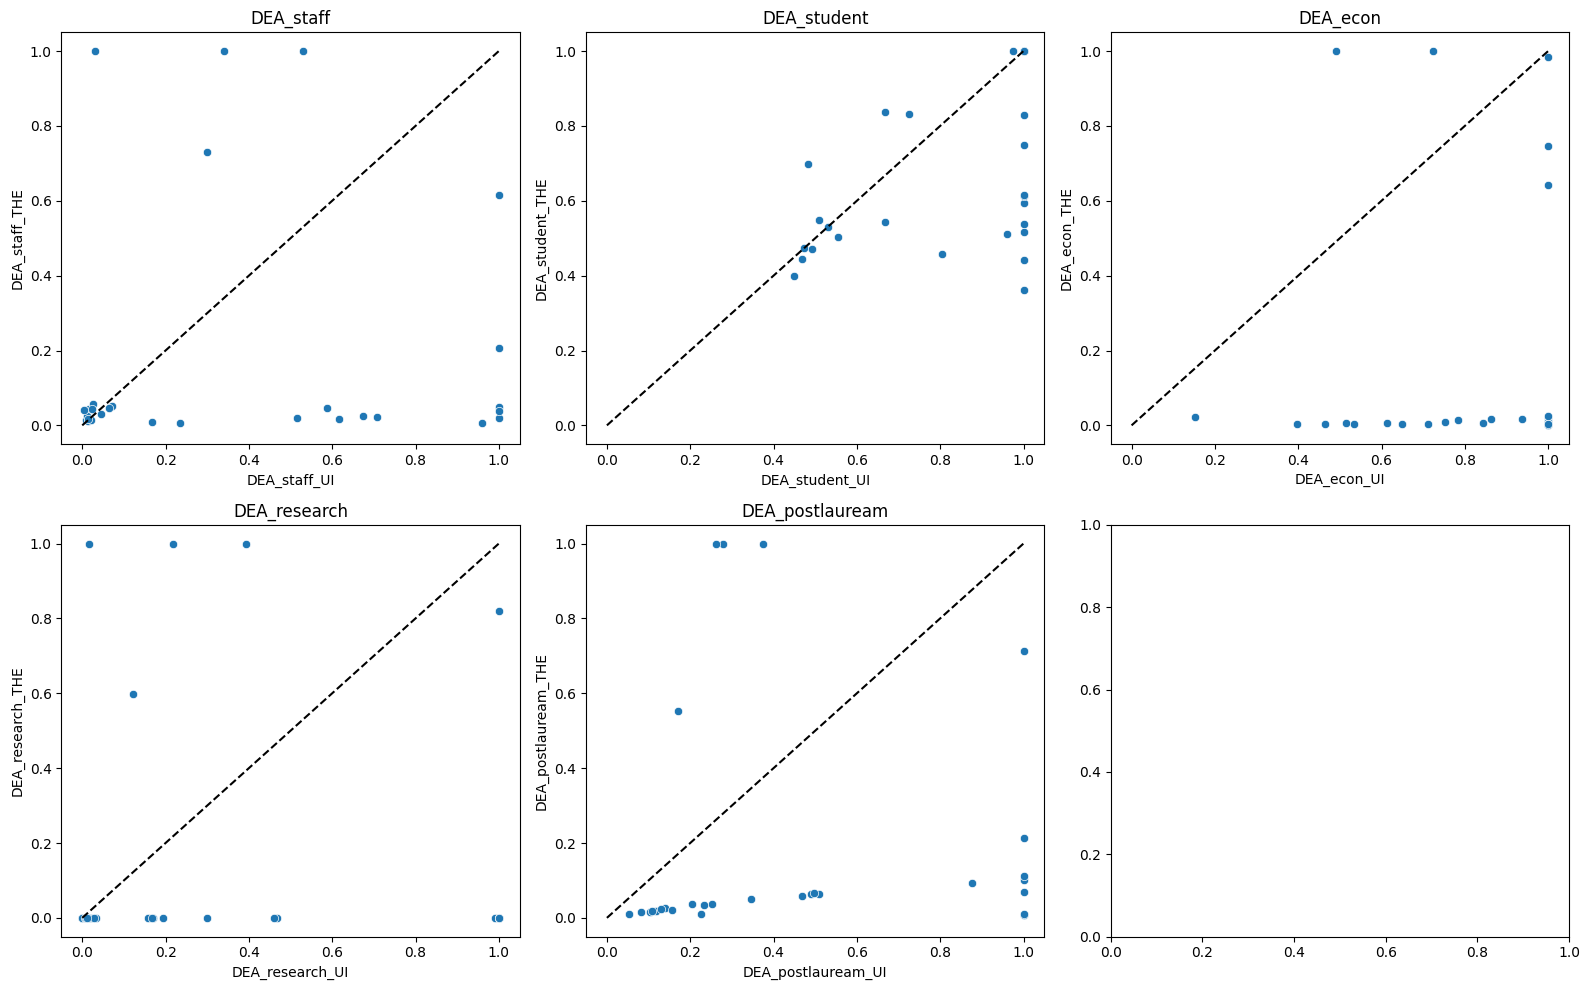

In [200]:
# Multi-panel scatter (clean + informative)
import matplotlib.pyplot as plt
import seaborn as sns

merged = UI_dea_results.merge(
    THE_dea_results,
    on="UNIVERSITY_ID",
    suffixes=("_UI", "_THE")
)

metrics = [
    "DEA_staff",
    "DEA_student",
    "DEA_econ",
    "DEA_research",
    "DEA_postlauream"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, m in enumerate(metrics):
    sns.scatterplot(
        data=merged,
        x=f"{m}_UI",
        y=f"{m}_THE",
        ax=axes[i]
    )

    axes[i].plot([0,1],[0,1],"--", color="black")
    axes[i].set_title(m)

plt.tight_layout()
plt.show()

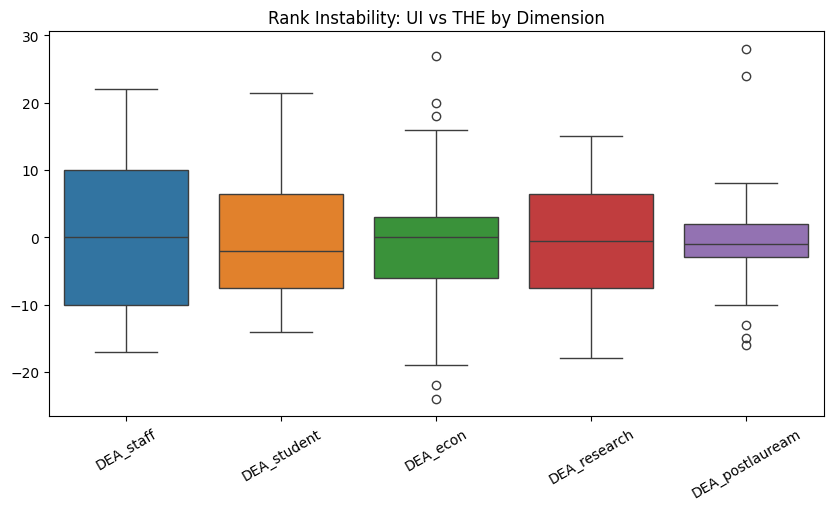

In [202]:
# Much better: rank instability (this is the real insight)

# DEA values being ~1 is fine — ranks still matter
metrics = [
    "DEA_staff",
    "DEA_student",
    "DEA_econ",
    "DEA_research",
    "DEA_postlauream"
]

rank_df = merged[["UNIVERSITY_ID"]].copy()

for m in metrics:
    rank_df[f"{m}_UI_rank"] = merged[f"{m}_UI"].rank(ascending=False)
    rank_df[f"{m}_THE_rank"] = merged[f"{m}_THE"].rank(ascending=False)
    rank_df[f"{m}_diff"] = rank_df[f"{m}_THE_rank"] - rank_df[f"{m}_UI_rank"]

plt.figure(figsize=(10,5))
sns.boxplot(data=rank_df[[f"{m}_diff" for m in metrics]])

plt.xticks(range(len(metrics)), metrics, rotation=30)
plt.title("Rank Instability: UI vs THE by Dimension")
plt.show()

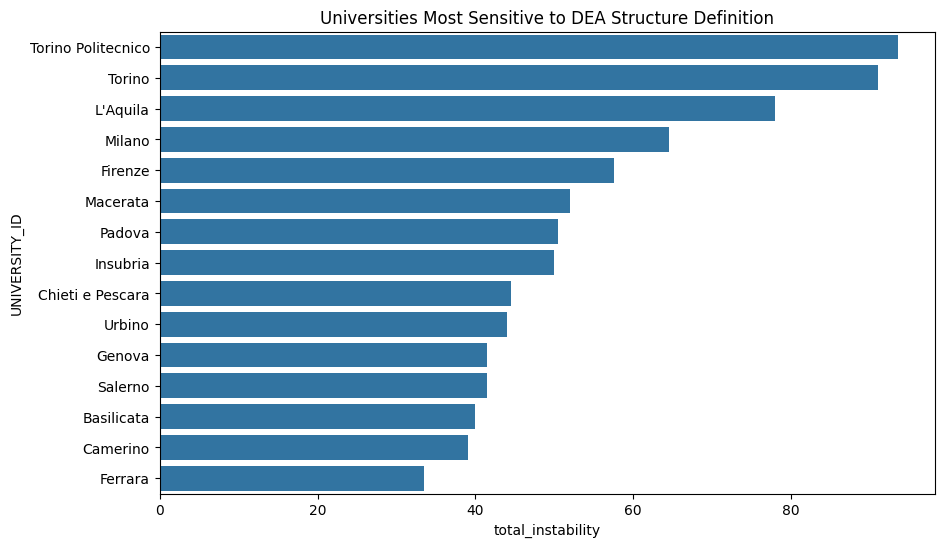

In [205]:
# “Which universities are structurally sensitive?”

# This finds universities where methodology changes everything.
rank_df["total_instability"] = rank_df[[f"{m}_diff" for m in metrics]].abs().sum(axis=1)

top_sensitive = rank_df.sort_values("total_instability", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_sensitive,
    y="UNIVERSITY_ID",
    x="total_instability"
)

plt.title("Universities Most Sensitive to DEA Structure Definition")
plt.show()

In [206]:
import numpy as np
import matplotlib.pyplot as plt

metrics = [
    "DEA_staff",
    "DEA_student",
    "DEA_econ",
    "DEA_research",
    "DEA_postlauream"
]

def radar_plot(univ_id, merged):
    
    row = merged[merged["UNIVERSITY_ID"] == univ_id]
    
    if row.empty:
        print("University not found")
        return
    
    ui_vals = row[[m + "_UI" for m in metrics]].values.flatten().tolist()
    the_vals = row[[m + "_THE" for m in metrics]].values.flatten().tolist()

    labels = metrics
    n = len(labels)

    angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    ui_vals += ui_vals[:1]
    the_vals += the_vals[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

    ax.plot(angles, ui_vals, label="UI", linewidth=2)
    ax.fill(angles, ui_vals, alpha=0.15)

    ax.plot(angles, the_vals, label="THE", linewidth=2)
    ax.fill(angles, the_vals, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)

    ax.set_title(f"Structural Efficiency Radar: {univ_id}")
    ax.legend(loc="upper right")

    plt.show()

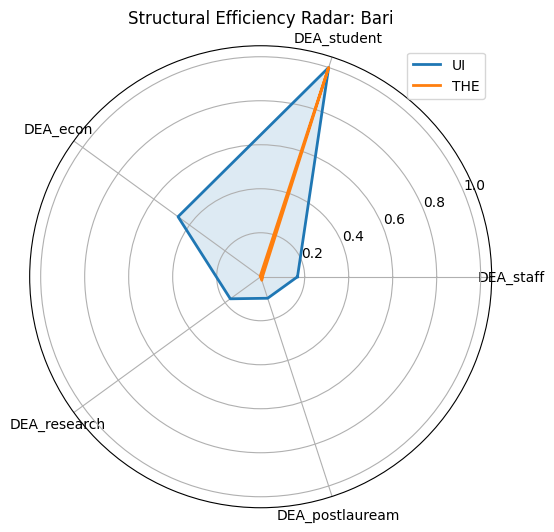

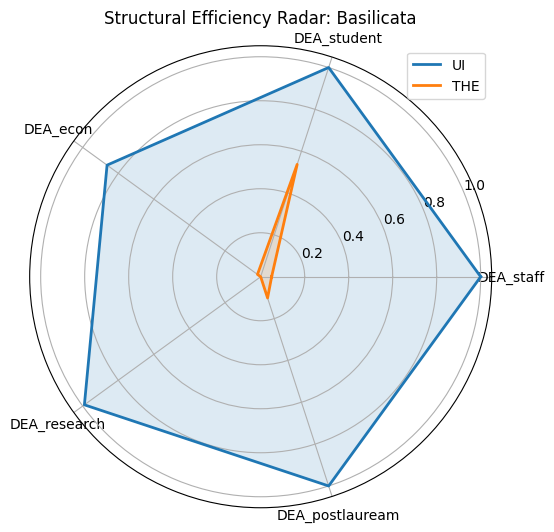

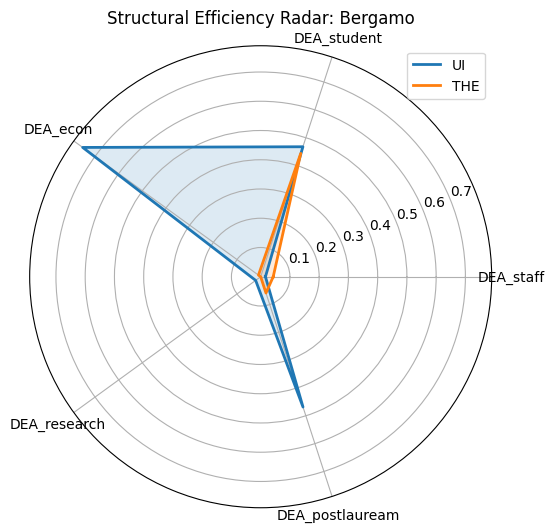

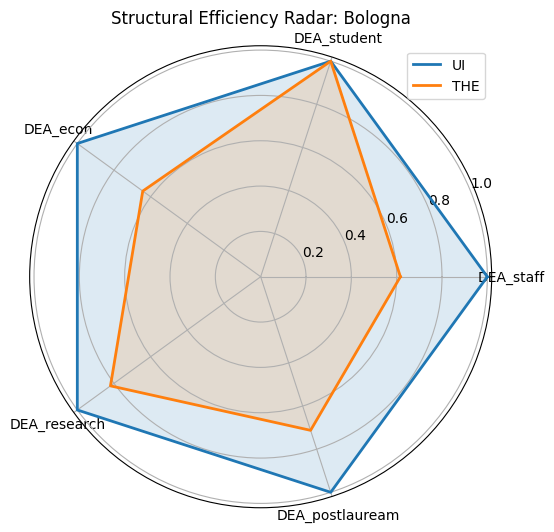

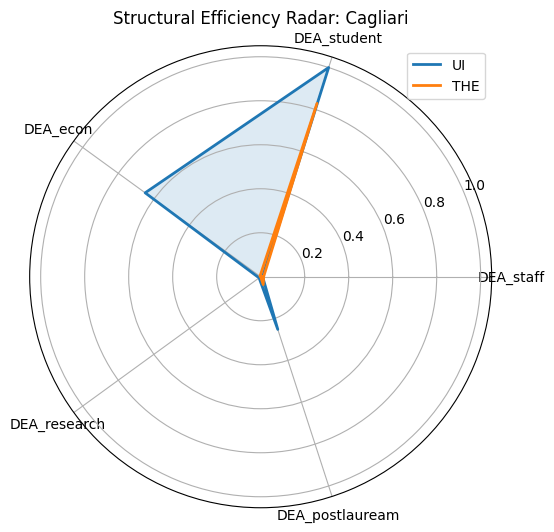

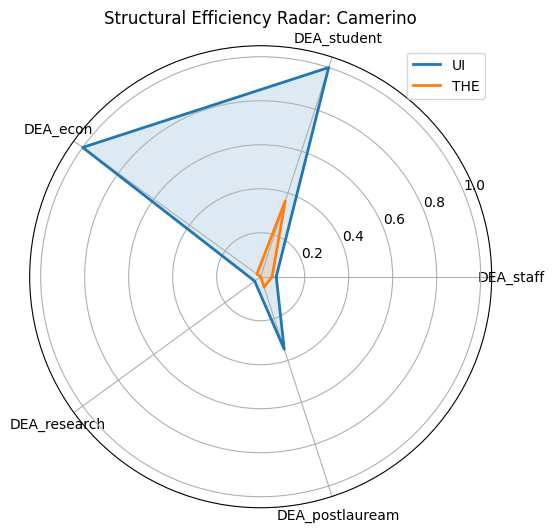

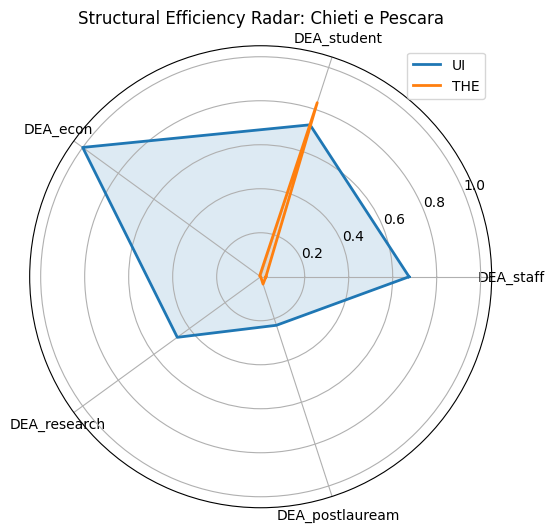

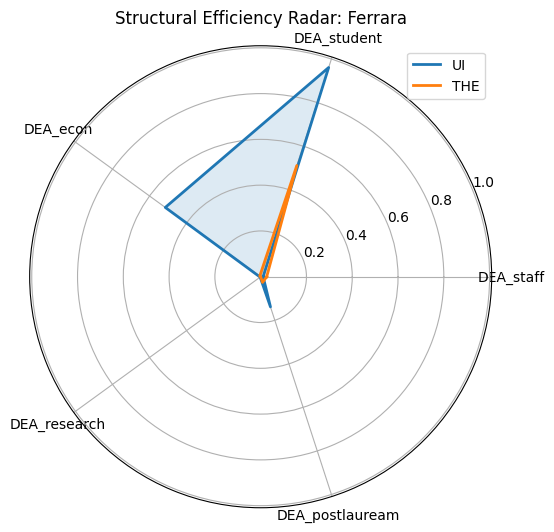

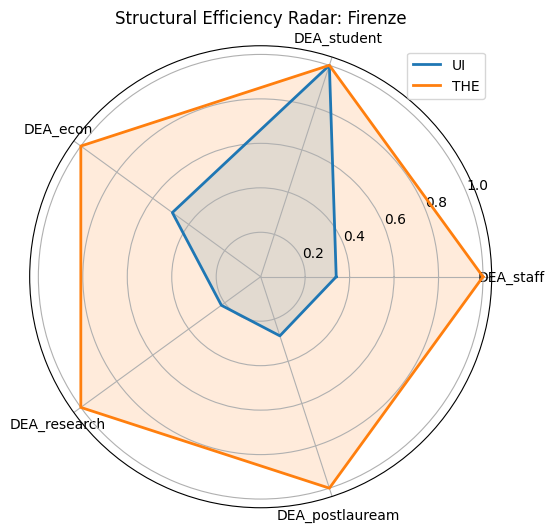

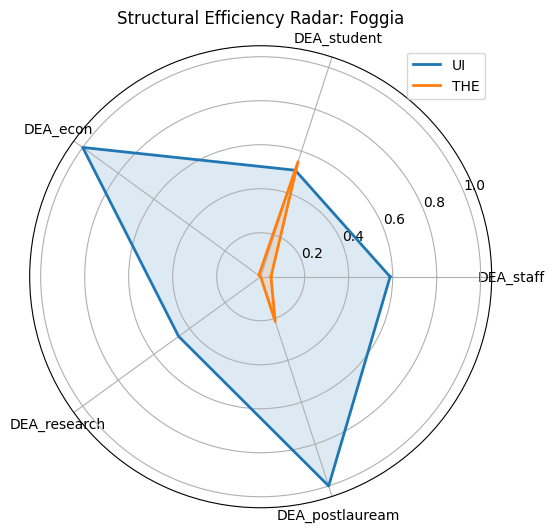

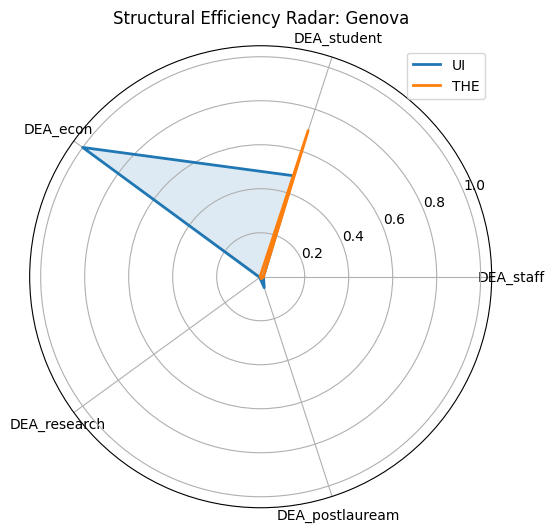

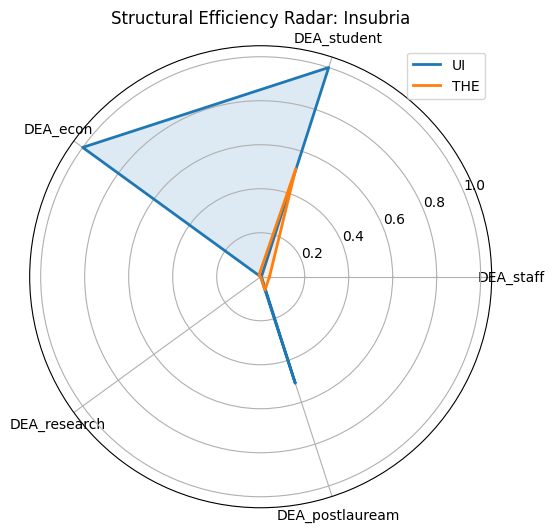

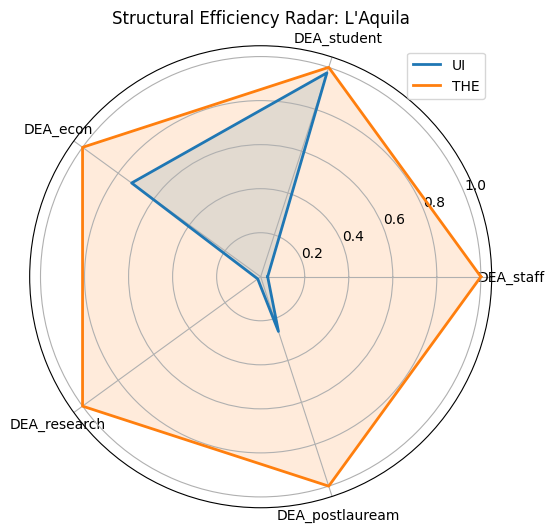

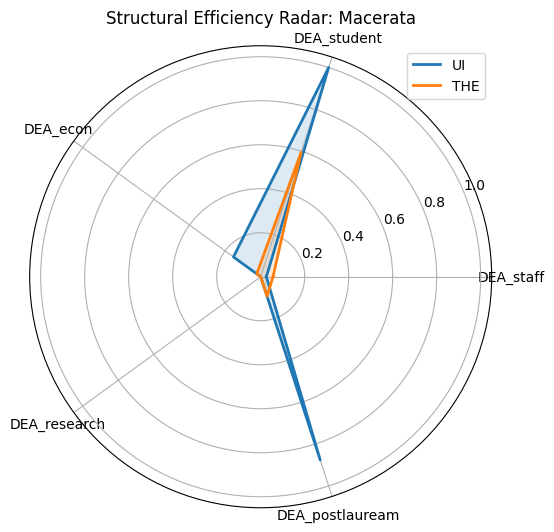

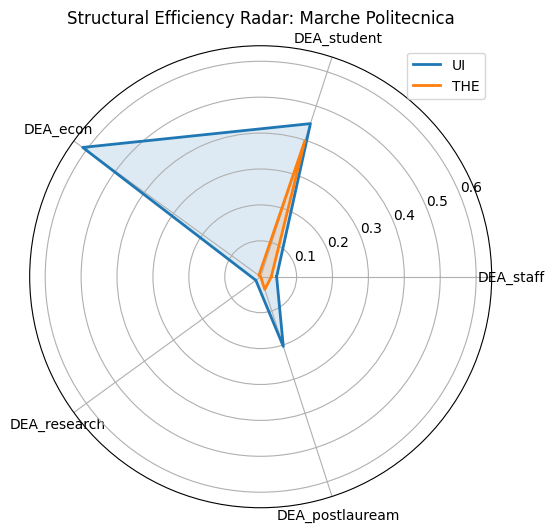

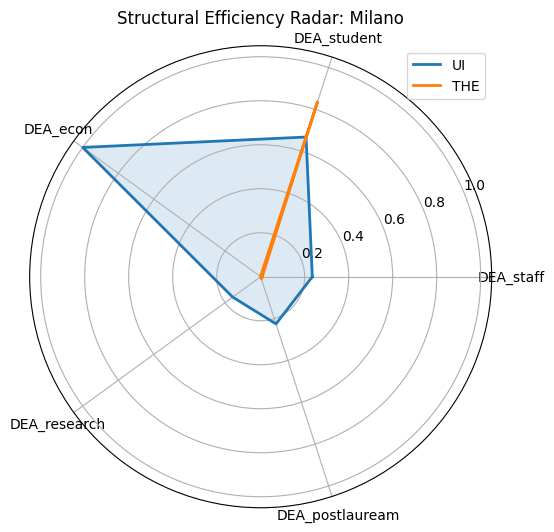

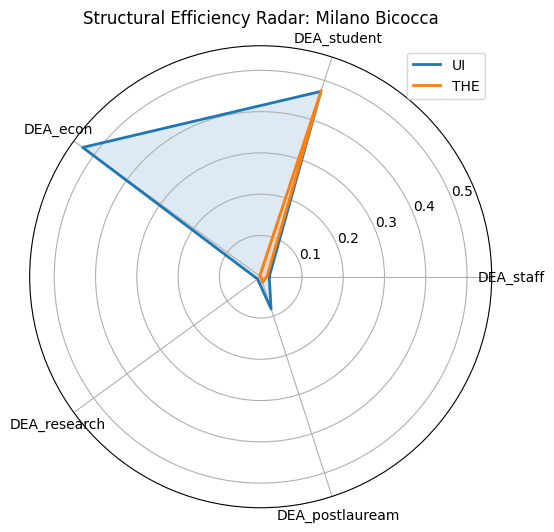

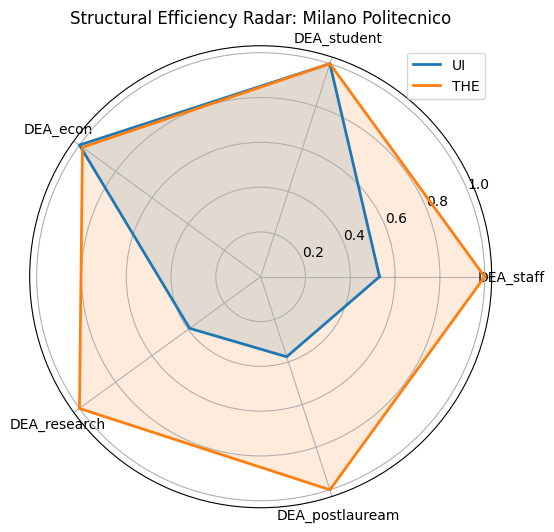

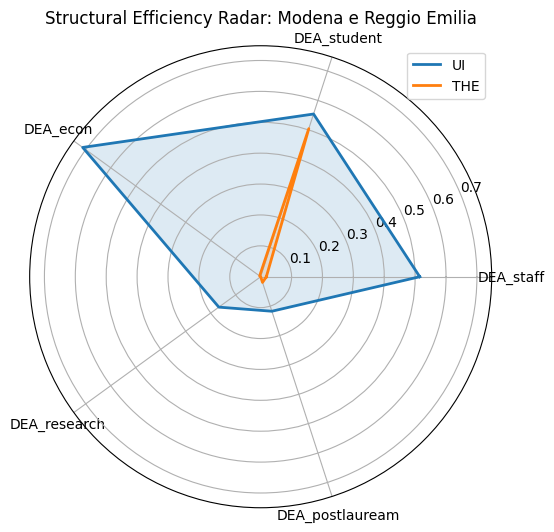

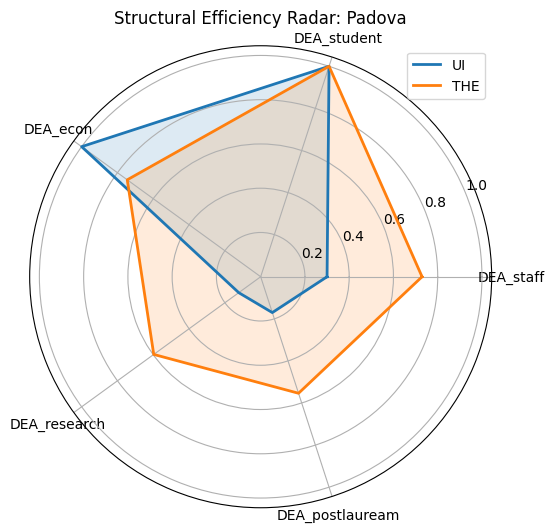

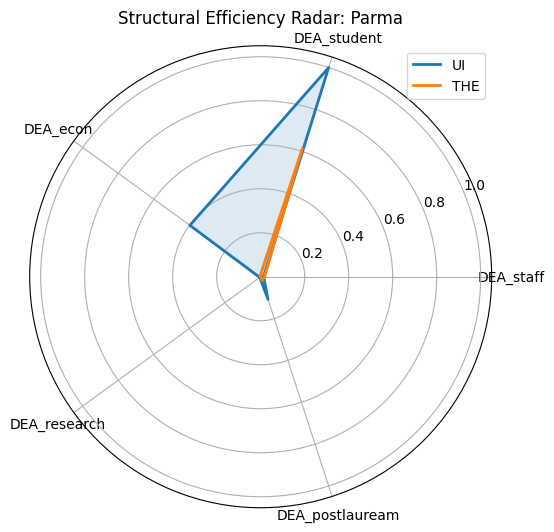

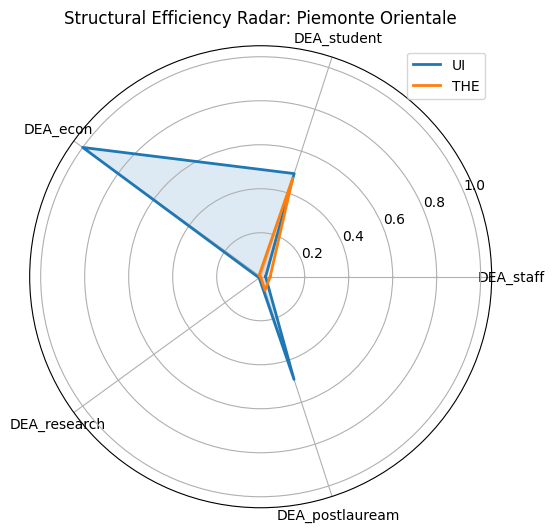

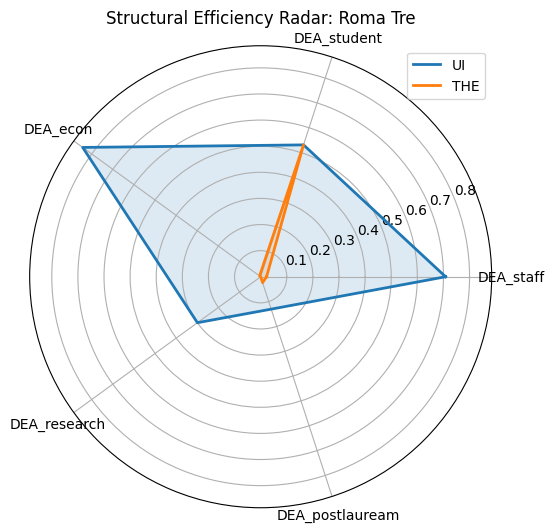

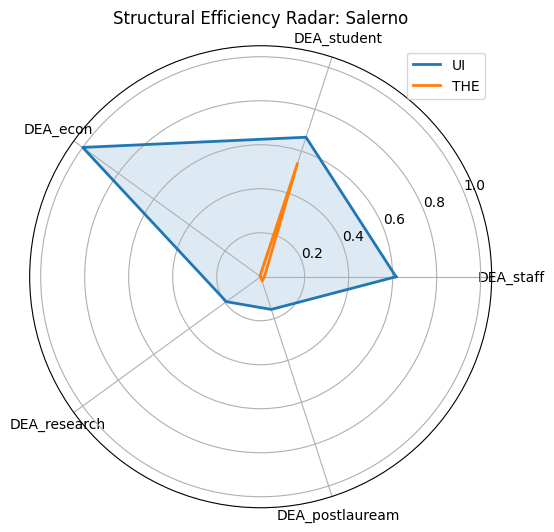

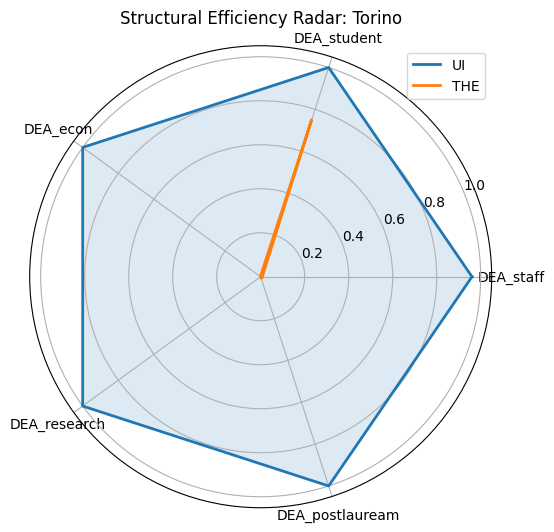

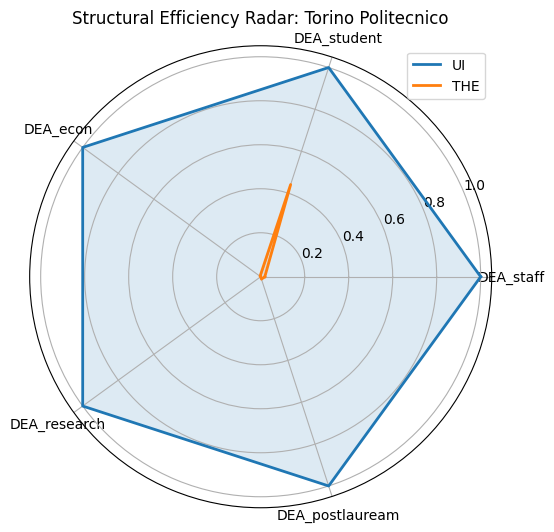

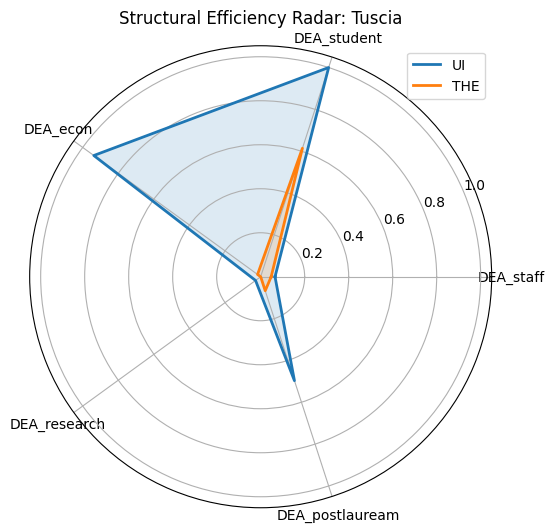

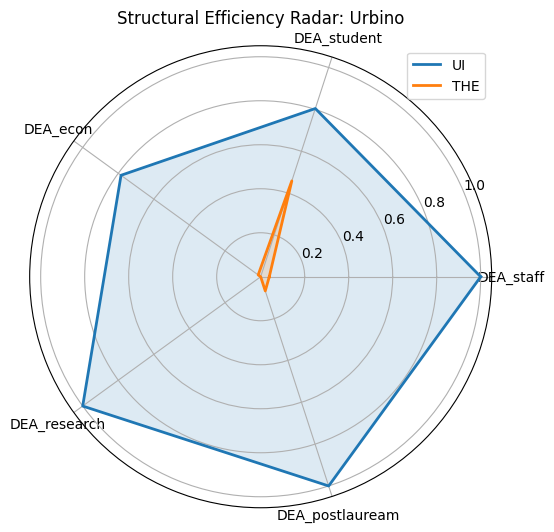

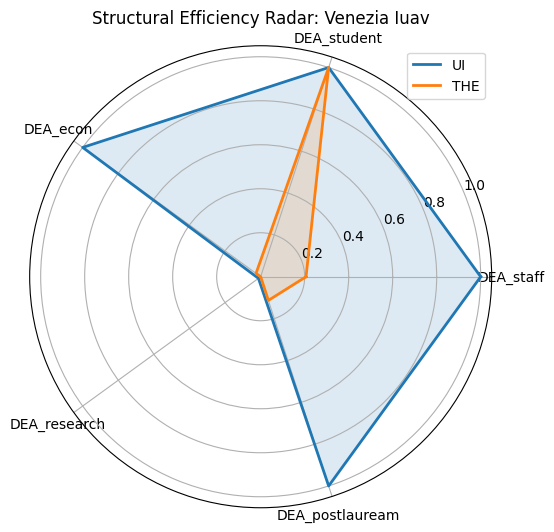

In [207]:
top_unis = merged["UNIVERSITY_ID"]

for u in top_unis:
    radar_plot(u, merged)

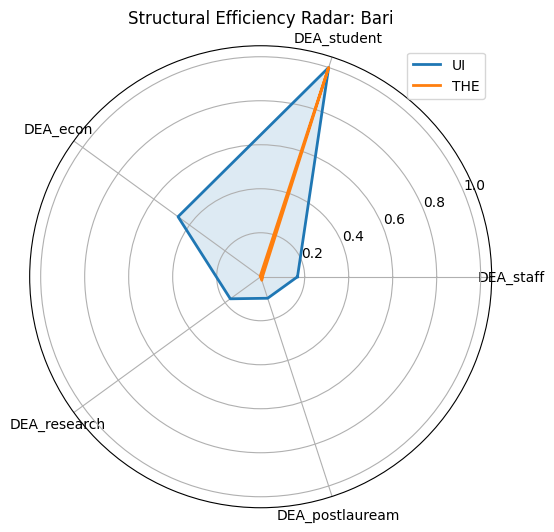

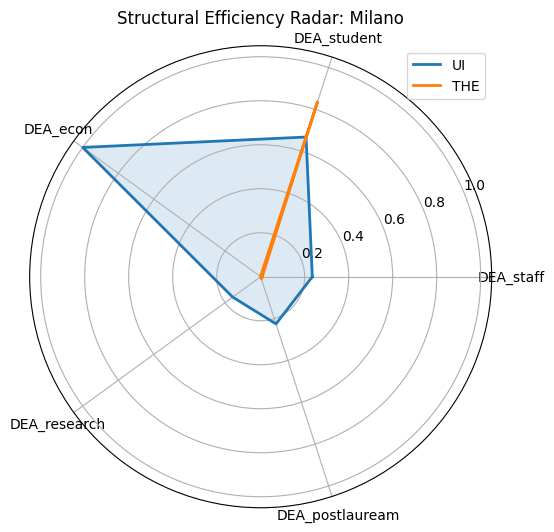

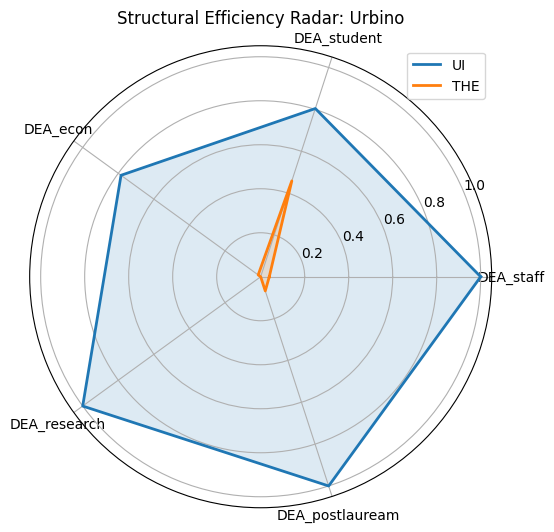

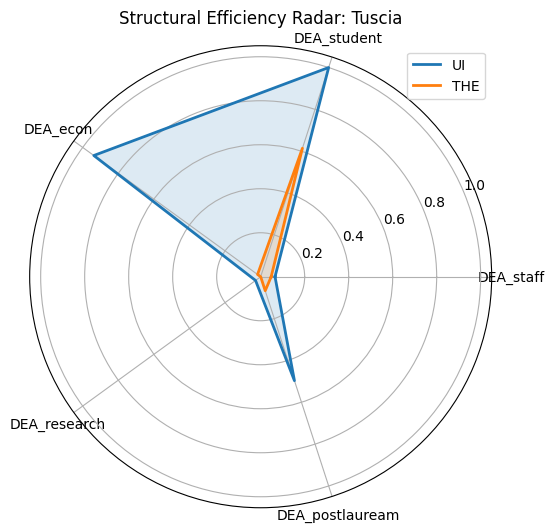

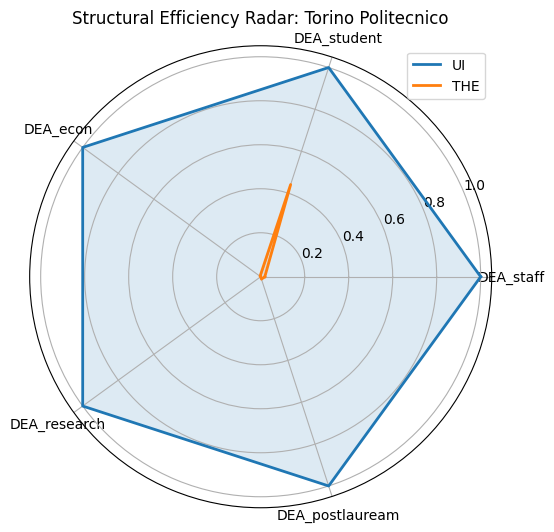

In [208]:
merged["instability"] = (
    (merged[[m+"_UI" for m in metrics]] -
     merged[[m+"_THE" for m in metrics]]).abs().sum(axis=1)
)

interesting = merged.sort_values("instability", ascending=False).head(5)

for u in interesting["UNIVERSITY_ID"]:
    radar_plot(u, merged)

In [209]:
# =========================
# COST ASSUMPTIONS (toy model)
# =========================

cost_per_unit = {
    # STAFF
    "STAFF | UNIVERSITY STAFF_2023": 50000,
    "STAFF | FULL PROFESSORS_2023": 120000,
    "STAFF | ASSOCIATE PROFESSOR _2023": 90000,
    "STAFF | TENURED RESEARCHERS_2023": 100000,
    "STAFF | FIXED-TERM RESEARCHERS_2023": 70000,

    # STUDENTS (proxy costs)
    "STUDENT LIFECYCLE | NUMBER OF ENROLLED STUDENTS_2023": 10000,
    "STUDENT LIFECYCLE | NUMBER OF GRADUATES_2023": 15000,
    "STUDENT LIFECYCLE | STUDENT-STAFF RATIO_2023": 0,  # derived metric
    "STUDENT LIFECYCLE | PERCENTAGE OF GRADUATES SATISFIED WITH THE DEGREE PROGRAMMES_2023": 20000,
    "STUDENT LIFECYCLE | PERCENTAGE OF GRADUATES EMPLOYED ONE YEAR AFTER GRADUATION _2023": 25000,

    # ECONOMIC
    "ECONOMIC AND FINANCIAL | TOTAL REVENUES_2023": 1.0,
    "ECONOMIC AND FINANCIAL | TOTAL EXPENDITURES_2023": 1.0,
    "ECONOMIC AND FINANCIAL | PUBLIC REVENUES_2023": 1.0,
    "ECONOMIC AND FINANCIAL | OPERATING REVENUES_2023": 1.0,
    "ECONOMIC AND FINANCIAL | OPERATING COSTS_2023": 1.0,

    # RESEARCH
    "RESEARCH | HIGHLY CITED RESEARCHERS _2023": 200000,
    "RESEARCH | ARTICLES PUBLISHED IN NATURE AND SCIENCE _2023": 50000,

    # POST-LAUREAM
    "POST LAUREAM EDUCATION | STUDENTS ENROLLED IN PHD PROGRAMMES_2023": 30000,
    "POST LAUREAM EDUCATION | PHDS AWARDED_2023": 40000,
    "POST LAUREAM EDUCATION | FIRST-LEVEL MASTER’S DEGREES AWARDED_2023": 20000,
    "POST LAUREAM EDUCATION | SECOND-LEVEL MASTER’S DEGREES AWARDED_2023": 20000,
}

In [210]:
def compute_cost(df, inputs, cost_dict):
    total_cost = np.zeros(len(df))

    for col in inputs:
        if col in df.columns:
            cost = cost_dict.get(col, 0)
            total_cost += df[col].fillna(0).values * cost

    return total_cost

In [211]:
# choose outputs (keep your current logic)
outputs = ["GLOBAL_2023"]

all_inputs = staff_inputs + student_inputs + econ_inputs + research_inputs + post_inputs

# ---- run DEA ----
UI_final["DEA_overall"] = dea_vrs(UI_final, all_inputs, outputs)

# ---- compute cost proxy ----
UI_final["TOTAL_COST"] = compute_cost(UI_final, all_inputs, cost_per_unit)

# ---- cost-adjusted efficiency idea ----
UI_final["DEA_per_cost"] = UI_final["DEA_overall"] / (UI_final["TOTAL_COST"] + 1e-9)

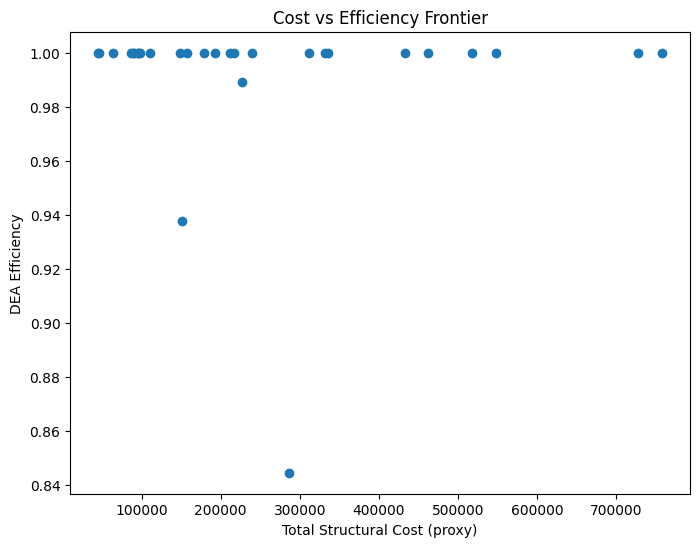

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    UI_final["TOTAL_COST"],
    UI_final["DEA_overall"]
)

plt.xlabel("Total Structural Cost (proxy)")
plt.ylabel("DEA Efficiency")
plt.title("Cost vs Efficiency Frontier")

plt.show()

In [219]:
[x for x in UI_final.columns]

['STAFF | INTERNAL TEACHING STAFF',
 'STAFF | AVERAGE AGE OF INTERNAL TEACHING STAFF',
 'STAFF | FULL PROFESSORS',
 'STAFF | AVERAGE AGE OF FULL PROFESSORS ',
 'STAFF | ASSOCIATE PROFESSOR ',
 'STAFF | AVERAGE AGE OF ASSOCIATE PROFESSORS',
 'STAFF | TENURED RESEARCHERS',
 'STAFF | AVERAGE AGE OF TENURED RESEARCHERS',
 'STAFF | FIXED-TERM RESEARCHERS',
 'STAFF | AVERAGE AGE OF FIXED-TERM RESEARCHERS',
 'STAFF | RESEARCH FELLOWS',
 'STAFF | AVERAGE AGE OF RESEARCH FELLOWS',
 'STAFF | EXECUTIVE TECHNICAL ADMINISTRATIVE STAFF',
 'STAFF | COLLABORATORS IN RESEARCH ACTIVITIES',
 'STAFF | INTERNAL TEACHING STAFF AND RESEARCH FELLOWS',
 'STAFF | NON-ACADEMIC STAFF',
 'STAFF | UNIVERSITY STAFF',
 'STAFF | ADJUNCT FACULTY',
 'STUDENT LIFECYCLE | NUMBER OF FIRST-YEAR ENTRANCE',
 'STUDENT LIFECYCLE | NUMBER OF FIRST-TIME ENTRANCE',
 'STUDENT LIFECYCLE | NUMBER OF ENROLLED STUDENTS',
 'STUDENT LIFECYCLE | NUMBER OF FIRST-YEAR ENROLLED STUDENTS',
 'STUDENT LIFECYCLE | NUMBER OF REGULAR STUDENTS',
 '

In [214]:
pip install streamlit

  Using cached websockets-16.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 559.7 kB/s  0:00:16m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.5/797.5 kB 472.2 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 494.7 kB/s  0:00:22m0:00:0100:01
Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 528.0 kB/s  0:01:01m0:00:0100:02
Using cached referencing-0.37.0-py3-none-any.whl (26 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
Using cached websockets-16.0-cp311-cp311-macosx_11_0_arm64.whl (175 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25/25 [streamlit]25 [streamlit]

[notice] A new r

In [230]:
THE_final

,STAFF | INTERNAL TEACHING STAFF,STAFF | AVERAGE AGE OF INTERNAL TEACHING STAFF,STAFF | FULL PROFESSORS,STAFF | AVERAGE AGE OF FULL PROFESSORS,STAFF | ASSOCIATE PROFESSOR,STAFF | AVERAGE AGE OF ASSOCIATE PROFESSORS,STAFF | TENURED RESEARCHERS,STAFF | AVERAGE AGE OF TENURED RESEARCHERS,STAFF | FIXED-TERM RESEARCHERS,STAFF | AVERAGE AGE OF FIXED-TERM RESEARCHERS,...,Partnership for the goals_chg_3y,Partnership for the goals_accel,DEA_eff_to_sus,DEA_sus_to_eff,DEA_overall,DEA_staff,DEA_student,DEA_econ,DEA_research,DEA_postlauream
UNIVERSITY_ID,,,,,,,,,,,,,,,,,,,,,
Bari,1575,50.9,313,58.3,660,52.9,208,55.6,394,39.4,...,0.0,0.0,NaN,NaN,1.000000,0.008033,1.000000,0.002830,0.000000,0.016760
Bologna,3374,50.2,932,57.7,1435,51.3,178,57.3,829,38.4,...,0.0,0.0,NaN,NaN,1.000000,0.616470,1.000000,0.643053,0.819132,0.712598
Brescia,659,50.3,187,57.7,267,51.1,53,54.4,152,38.3,...,0.0,0.0,NaN,NaN,0.700879,0.026731,0.501183,0.005905,0.000000,0.040214
Camerino,317,53.2,73,59.6,129,54.4,46,58.6,69,40.6,...,0.0,0.0,NaN,NaN,0.908892,0.051888,0.362104,0.021173,0.000000,0.049917
Firenze,1864,51.7,384,60.3,854,53.8,117,58.6,509,40.2,...,0.0,0.0,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Foggia,430,50.9,146,56.9,157,51.4,32,54.0,95,39.7,...,0.0,0.0,NaN,NaN,1.000000,0.046938,0.549848,0.010546,-0.000000,0.214286
Insubria,436,52.1,113,58.6,199,53.0,37,56.5,87,39.7,...,0.0,0.0,NaN,NaN,0.601665,0.040124,0.516696,0.010425,0.000000,0.063380
L'Aquila,640,52.0,183,59.3,235,52.8,63,58.8,159,39.5,...,0.0,0.0,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Marche Politecnica,653,50.2,175,58.8,256,51.9,40,55.3,182,38.4,...,0.0,0.0,NaN,NaN,0.424591,0.029570,0.398206,0.006210,0.000000,0.037143


In [226]:
THE_final = THE_final.dropna(subset=["OVERALL"]).copy()

In [232]:
UI_final.to_csv("UI_final.csv")
THE_final.to_csv("THE_final.csv")